# Cyberbullying Detection - Model Training & Evaluation

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pickle

print("All libraries imported!")

All libraries imported!


## Step 1: Load Cleaned Dataset

In [ ]:
# Load cleaned dataset
df = pd.read_csv('../dataset/cleaned_dataset.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (47656, 3)


,tweet_text,cyberbullying_type,cleaned_text
0,"In other words #katandandre, your food was cra...",not_cyberbullying,in other words katandandre your food was crapi...
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,why is aussietv so white mkr theblock imaceleb...
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,xochitlsuckkks a classy whore or more red velv...
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,jasongio meh p thanks for the heads up but no...
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,rudhoeenglish this is an isis account pretendi...


In [ ]:
# Remove NaN values from cleaned_text
df['cleaned_text'] = df['cleaned_text'].fillna('')
df = df[df['cleaned_text'].str.strip() != '']
df = df.dropna(subset=['cleaned_text'])
print("NaN values removed!")
print("Dataset shape:", df.shape)

NaN values removed!
Dataset shape: (47535, 3)


## Step 2: Feature Extraction using TF-IDF

In [ ]:
# TF-IDF Vectorization
X = df['cleaned_text']
y = df['cyberbullying_type']

vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (38028, 5000)
Testing size: (9507, 5000)


## Step 3: Train Multiple Models and Compare

In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }
    print(f"{name} - Accuracy: {results[name]['Accuracy']:.2f}")

Logistic Regression - Accuracy: 0.83
Decision Tree - Accuracy: 0.78
Random Forest - Accuracy: 0.81


## Step 4: Model Comparison

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.830756   0.832077  0.830756  0.830852
Decision Tree        0.777953   0.780980  0.777953  0.779417
Random Forest        0.806458   0.813034  0.806458  0.807334


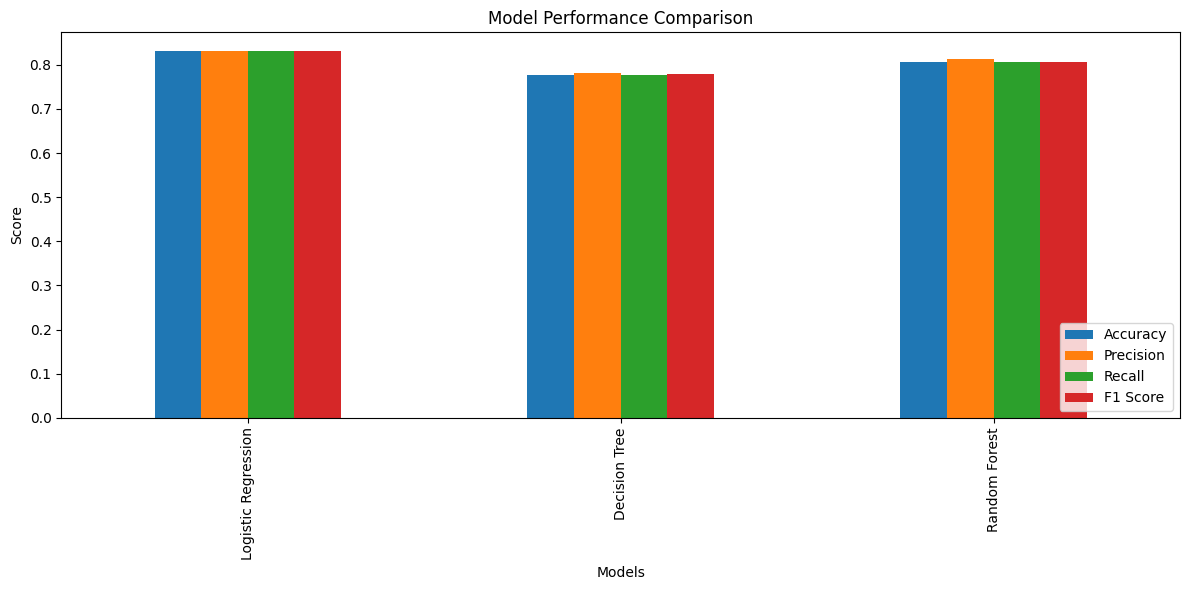

In [ ]:
# Compare all models
results_df = pd.DataFrame(results).T
print(results_df)

# Plot comparison
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 5: Best Model Evaluation
Logistic Regression selected as best model based on performance.

In [ ]:
# Best model - Logistic Regression
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Detailed Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                     precision    recall  f1-score   support

                age       0.95      0.97      0.96      1564
          ethnicity       0.97      0.98      0.97      1611
             gender       0.89      0.83      0.86      1539
  not_cyberbullying       0.61      0.57      0.59      1620
other_cyberbullying       0.63      0.69      0.66      1601
           religion       0.95      0.95      0.95      1572

           accuracy                           0.83      9507
          macro avg       0.83      0.83      0.83      9507
       weighted avg       0.83      0.83      0.83      9507



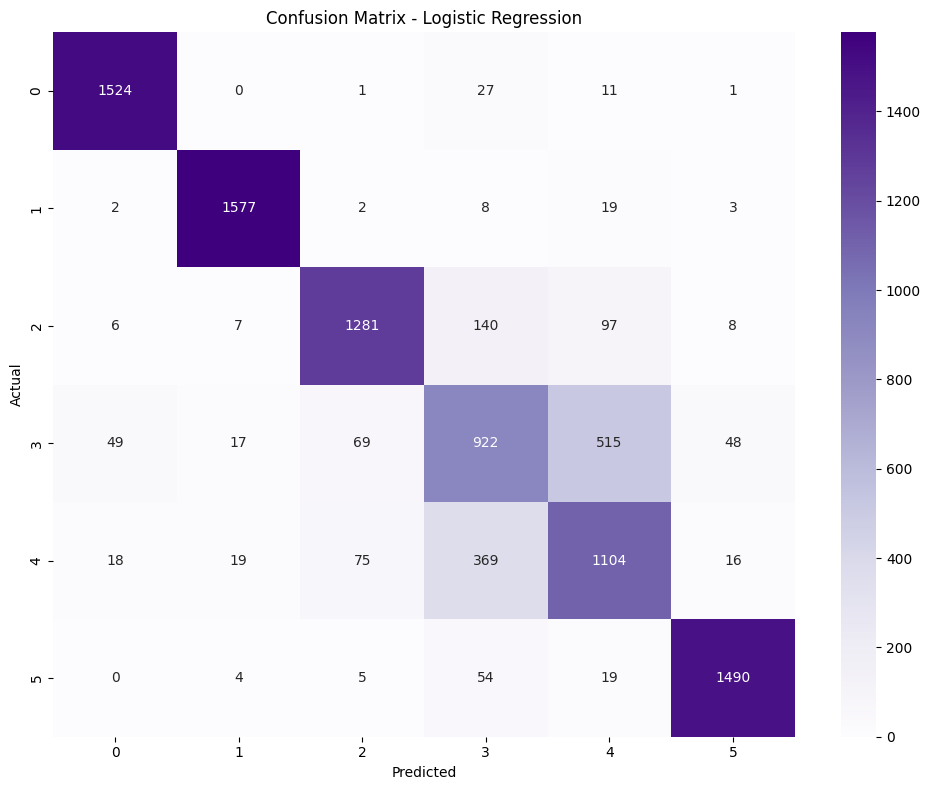

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 6: Save Best Model

In [ ]:
# Save model and vectorizer
pickle.dump(best_model, open('../backend/model/model.pkl', 'wb'))
pickle.dump(vectorizer, open('../backend/model/vectorizer.pkl', 'wb'))
print("Model saved successfully!")

Model saved successfully!
